<a href="https://colab.research.google.com/github/mannatdhull124/Heart-Disease-Risk-Classification/blob/main/Heart_Disease_Risk_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Problem Statement

The objective of this project is to predict the presence of heart disease in patients using machine learning techniques.

The dataset contains various medical attributes such as age, sex, chest pain type, blood pressure, cholesterol levels, and heart rate. These features help in determining whether a patient is likely to have heart disease.

Early detection of heart disease is crucial in healthcare, as it can help doctors take preventive measures and provide timely treatment.

The goal is to build a classification model using a Decision Tree that can accurately predict whether a patient has heart disease (target = 1) or not (target = 0).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
df = pd.read_csv('/content/heart.csv')

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


age - the age of the patient in years

sex - the sex of the patient(1= male, 0=female)

cp - the type of chest pain the patient has experienced (1=typical angina, 2=atypical angina, 3=non-anginal pain, 4=asymptomatic)

trestbps - the resting blood pressure of the patient in mm Hg.

chol - the serum cholestrol level of the patient in mg/dl.

fbs - the fasting blood sugar level of the patient, measured in mg/dl(1=high, 0=low)

restecg - the resting electrocardiographic results of the patient (0=normal, 1=ST-T wave abnormality, 2=left ventriculur hypertrophy)

thalach = the maximum heart rate achienved by the patient during excercise.

oldpeak - the ST depression induced by excercise relative to rest. slope: the slope of ST segment during peak excercise(1= upsloping, 2=flat, 3=downsloping)

ca - the number of major vessels coloured by flouroscopy(0-3).

thal - the type of thallium scan performed on the patient (1=fixed defect, 2=reversible defect, 3= normal)

target - the presence of heart disease in the patient(0=no disease, 1=disease present).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
col = list(df.columns)

In [ ]:
col

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

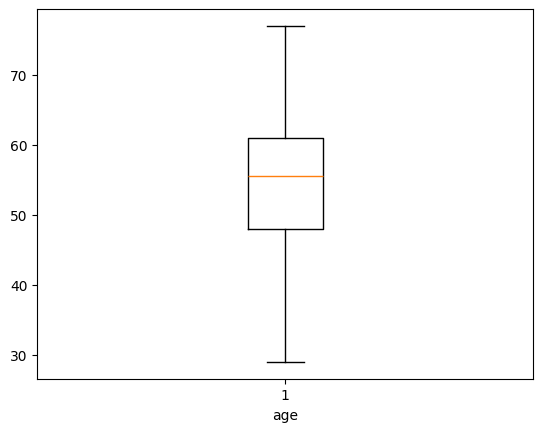

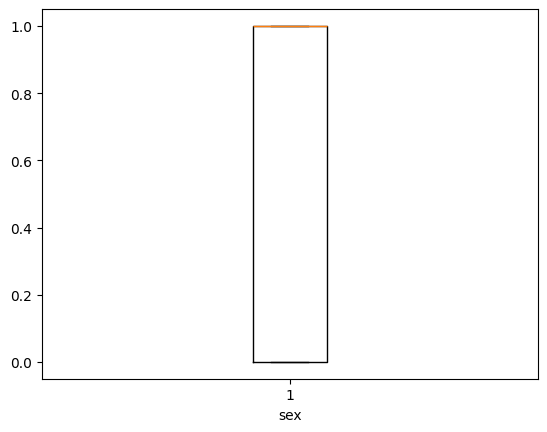

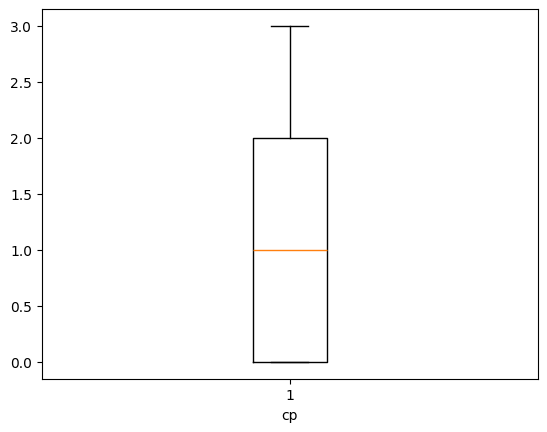

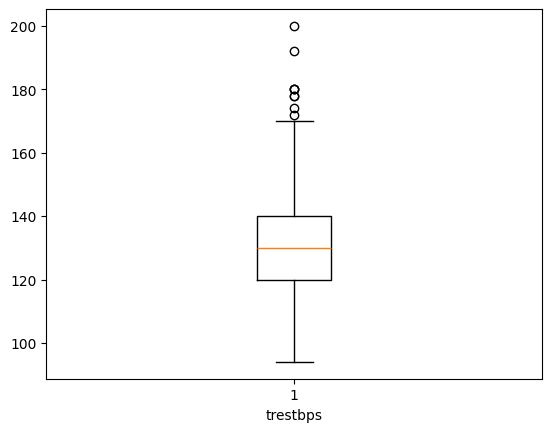

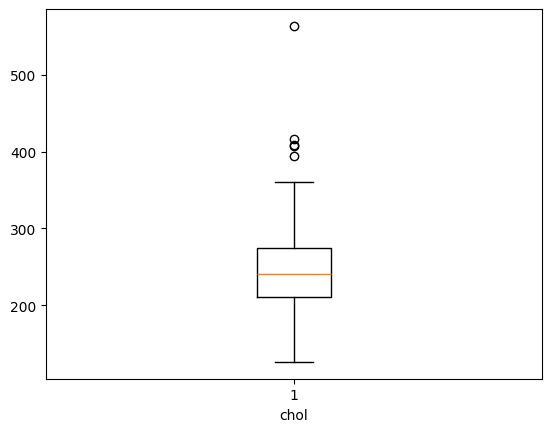

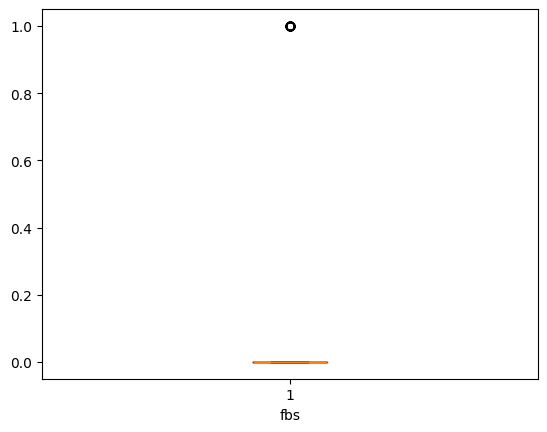

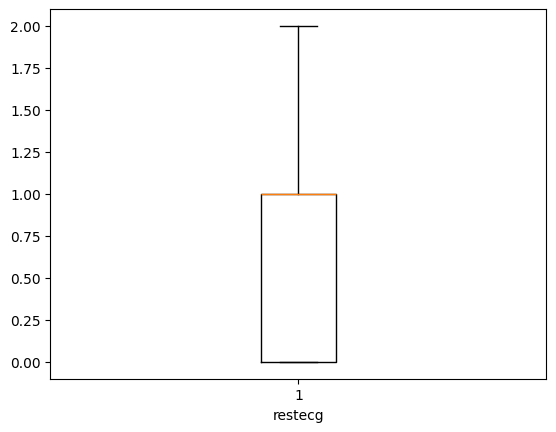

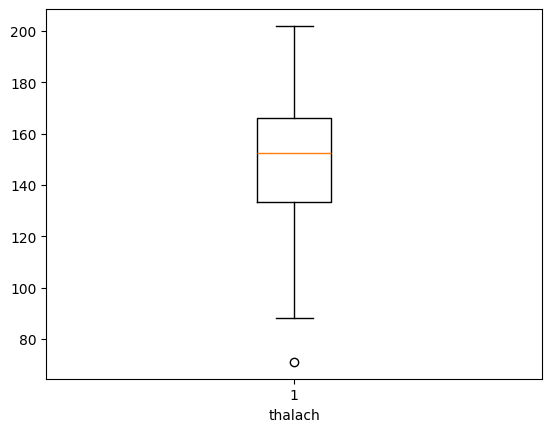

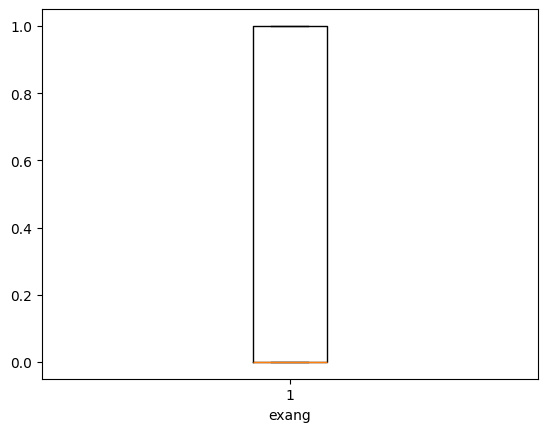

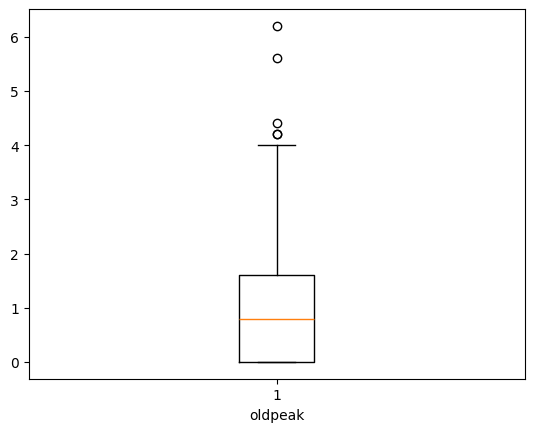

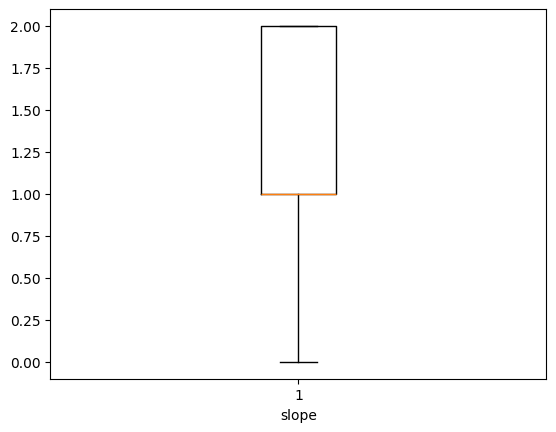

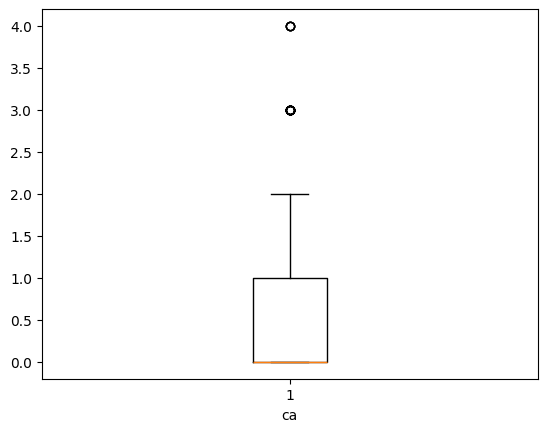

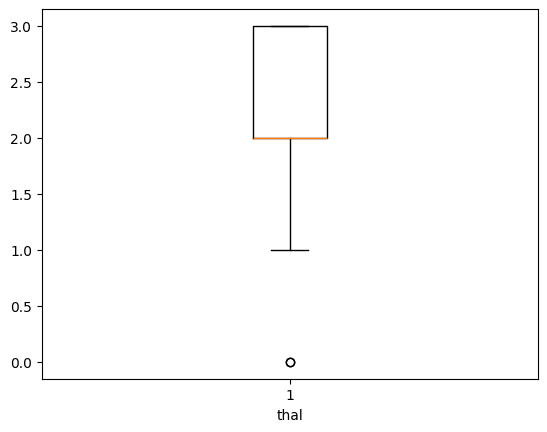

In [ ]:
for i in col:
  if(i!='target'):
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

<Axes: >

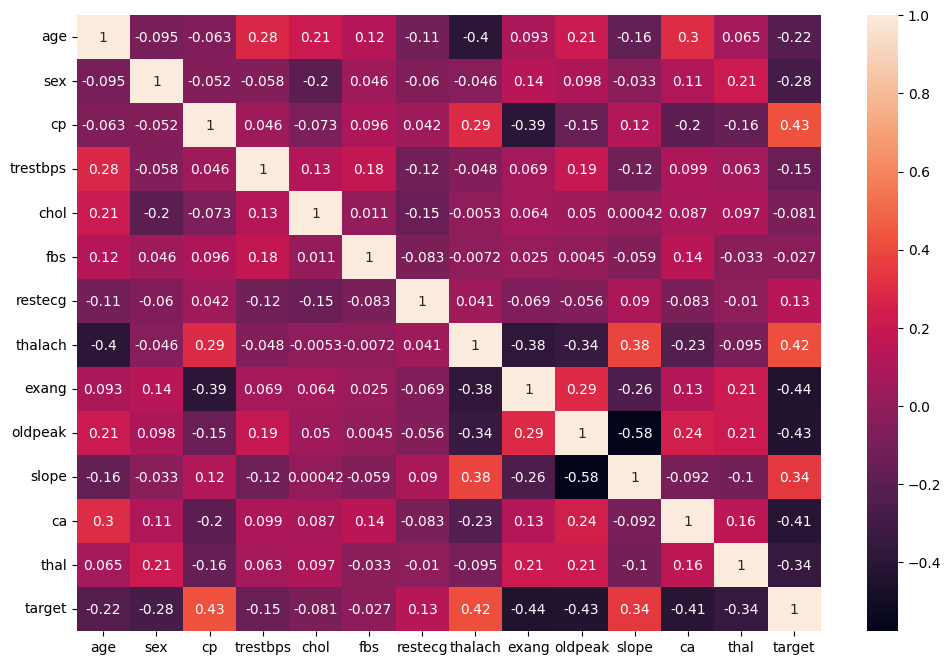

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

# ⚙️ Solution Approach

To solve the heart disease prediction problem, the following steps were performed:

1. Data Preprocessing:
   - Checked for missing values
   - Verified data types of all features
   - Encoded categorical variables where necessary

2. Exploratory Data Analysis (EDA):
   - Used count plots and histograms to understand feature distribution
   - Used boxplots to detect outliers
   - Analyzed relationships between features and target variable

3. Feature Selection:
   - Selected relevant medical attributes affecting heart disease

4. Model Building:
   - Implemented Decision Tree Classifier
   - The model splits data based on feature conditions to make predictions

5. Model Evaluation:
   - Evaluated using Accuracy Score, Confusion Matrix
   - Visualized the Decision Tree for better understanding

6. Interpretation:
   - Analyzed decision rules generated by the tree
   - Identified key features influencing predictions (e.g., cp, thalach, oldpeak)

In [ ]:
from sklearn.model_selection import train_test_split  # splitting the data in training and testing
from sklearn.metrics import accuracy_score, confusion_matrix   # to evaluate the model performance
from sklearn.tree import DecisionTreeClassifier  # load model library

In [ ]:
# divide the data into training and testing

x = df.drop(columns=['target'],axis=1)
y= df['target']

In [ ]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [ ]:
y

,target
0,1
1,1
2,1
3,1
4,1
...,...
298,0
299,0
300,0
301,0


In [ ]:
x_train, x_test, y_train, y_test= train_test_split(x,y,train_size=0.8, random_state=0)

In [ ]:
model=DecisionTreeClassifier()

In [ ]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_predict = model.predict(x_test)

In [ ]:
y_predict

array([0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
confusion_matrix(y_predict,y_test)

array([[22,  8],
       [ 5, 26]])

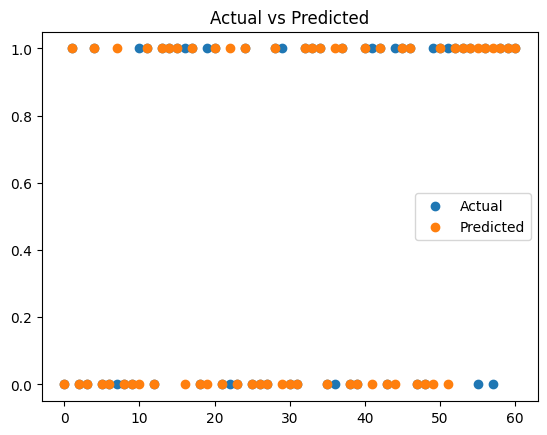

In [ ]:
plt.figure()
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_predict)), y_predict, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

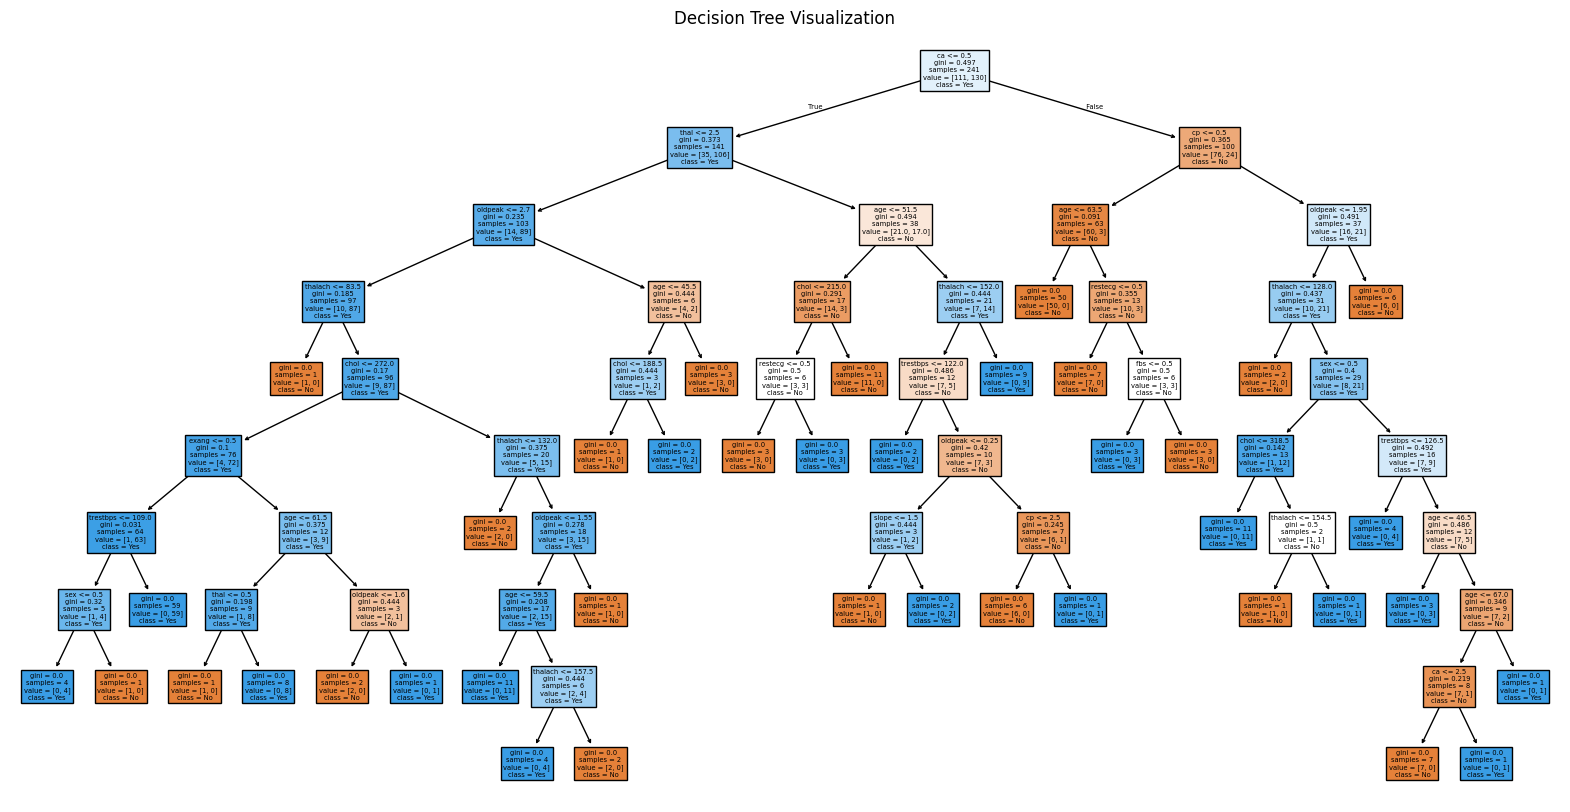

In [ ]:
from sklearn.tree import  plot_tree
# Plot tree
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=['No', 'Yes'],
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()

# 📈 Results and Conclusion

The Decision Tree model successfully predicted the presence of heart disease based on patient medical data.

The model provided clear decision rules, making it easy to interpret and understand.

Important features such as chest pain type (cp), maximum heart rate (thalach), and ST depression (oldpeak) played a significant role in prediction.

Decision Trees are highly useful in medical diagnosis because they are simple, interpretable, and provide clear insights into decision-making.

Thus, the model can assist healthcare professionals in early detection of heart disease.